In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
using LinearAlgebra
import Plots as plt

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
   1551.4 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 2 seconds. 20 already precompiled.


In [2]:
function f_cont(x, t)
    # Continuous dynamics: [velocity, constant acceleration]
    return [x[2], -9.81]
end

f_cont (generic function with 1 method)

In [3]:
function h_guard(x)
    # Guard surface: triggers when position hits 0
    return x[1] 
end

h_guard (generic function with 1 method)

In [4]:
function reset_map(x, t=0.0)
    return [x[1], -0.8 * x[2]]
end
# Adding the second argument 't' allows the Variational code to call it,

reset_map (generic function with 2 methods)

In [5]:
# Solve Standard System
sys = HD.GeneralSystem(f_cont, h_guard, reset_map)
prob = HD.prob(sys, [10.0, 0.0], (0.0, 15.0))
sol = HD.solve(prob, HD.RK23())

┌ Warning: Zeno Detected (Average Ratio = 0.8000006402291989) at t = 9.107577155353255. Terminating.
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Analysis\Pathology.jl:145


HybridDynamics.GeneralSolution{Vector{Float64}, Vector{Vector{Float64}}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  9.011823567814199, 9.021823567814199, 9.031823567814198, 9.041823567814198, 9.051823567814198, 9.061823567814198, 9.071823567814198, 9.081823567814197, 9.091823567814197, 9.101823567814197], [[10.0, 0.0], [9.9995095, -0.0981], [9.998038000000001, -0.1962], [9.9955855, -0.2943], [9.992152, -0.3924], [9.987737500000001, -0.49050000000000005], [9.982342000000001, -0.5886], [9.975965500000001, -0.6867], [9.968608000000001, -0.7847999999999999], [9.9602695, -0.8828999999999999]  …  [0.3945387504044962, -3.6505194922383017], [0.3575430554821132, -3.748619492238302], [0.31956636055973014, -3.846719492238302], [0.2806086656373471, -3.944819492238302], [0.24066997071496407, -4.042919492238302], [0.19975027579258103, -4.141019492238302], [0.15784958087019801, -4.239119492238301], [0.114967885947815, -4.337219492238301], [0.071105191025432, -4.435

In [6]:
# Plot Standard System
t_plot, X_plot = HD.split_jumps(sol)

# Extracting elements from a list of vectors
pos = [x[1] for x in X_plot]
vel = [x[2] for x in X_plot]

923-element Vector{Float64}:
  0.0
 -0.0981
 -0.1962
 -0.2943
 -0.3924
 -0.49050000000000005
 -0.5886
 -0.6867
 -0.7847999999999999
 -0.8828999999999999
  ⋮
 -3.748619492238302
 -3.846719492238302
 -3.944819492238302
 -4.042919492238302
 -4.141019492238302
 -4.239119492238301
 -4.337219492238301
 -4.435319492238301
 -4.5334194922383

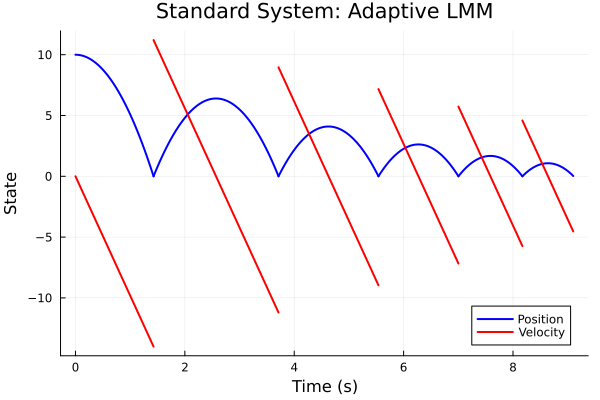

In [ ]:
p1 = plt.plot(t_plot, pos, label="Position", xlabel="Time (s)", ylabel="State", lw=2, color=:blue)
plt.plot!(p1, t_plot, vel, label="Velocity", lw=2, color=:red)
plt.title!("System Test")
p1

VARIATIONAL EQUATION TEST WITH GENERAL SYSTEM

In [8]:
# Dynamics for [x, Φ]
#f_aug(U, t) = HD.variational_vector_field(f_cont, U, t)

#This is needed if you DO NOT use MagnusLeapfrog method.  

In [9]:
# Reset for [x, Φ]
function reset_aug(U)
    return HD.apply_variational_jump(U, f_cont, reset_map, h_guard, 0.0)
end

reset_aug (generic function with 1 method)

In [10]:
# Guard for augmented state (check guard on x component)
h_aug(U) = h_guard(U[:, 1])

h_aug (generic function with 1 method)

In [11]:
sys_aug = HD.GeneralSystem(f_cont, h_guard, reset_aug) #Change to f_aug if not using magnusLeapfrog
U0 = hcat([10.0, 0.0], Matrix{Float64}(I, 2, 2))
prob_aug = HD.prob(sys_aug, U0, (0.0, 10.0))
sol_aug = HD.solve(prob_aug, HD.MagnusLeapfrog())

┌ Warning: Zeno Detected (Average Ratio = 0.800000640229199) at t = 9.107577155353257. Terminating.
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Analysis\Pathology.jl:145


HybridDynamics.GeneralSolution{Matrix{Float64}, Vector{Vector{Float64}}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  9.0118235678142, 9.0218235678142, 9.0318235678142, 9.0418235678142, 9.0518235678142, 9.0618235678142, 9.0718235678142, 9.0818235678142, 9.091823567814199, 9.101823567814199], [[10.0 1.0 0.0; 0.0 0.0 1.0], [9.9995095 1.0 0.01; -0.0981 0.0 1.0], [9.998038000000001 1.0 0.02; -0.1962 0.0 1.0], [9.9955855 1.0 0.03; -0.2943 0.0 1.0], [9.992152 1.0 0.04; -0.3924 0.0 1.0], [9.987737500000001 1.0 0.05; -0.49050000000000005 0.0 1.0], [9.982342000000001 1.0 0.060000000000000005; -0.5886 0.0 1.0], [9.975965500000001 1.0 0.07; -0.6867 0.0 1.0], [9.968608000000001 1.0 0.08; -0.7847999999999999 0.0 1.0], [9.9602695 1.0 0.09; -0.8828999999999999 0.0 1.0]  …  [0.39453875040449515 1.6843463086146615 0.37212227239942997; -3.6505194922383044 4.237779469759899 1.0000000000000209], [0.3575430554821121 1.7267241033122604 0.3821222723994302; -3.748619492238304

In [12]:
# Plot Augmented System
t_plot_aug, U_plot = HD.split_jumps(sol_aug)

pos_a   = [U[1, 1] for U in U_plot]
vel_a   = [U[2, 1] for U in U_plot]
phi_11  = [U[1, 2] for U in U_plot]
phi_12  = [U[1, 3] for U in U_plot]
phi_21  = [U[2, 2] for U in U_plot]
phi_22  = [U[2, 3] for U in U_plot];

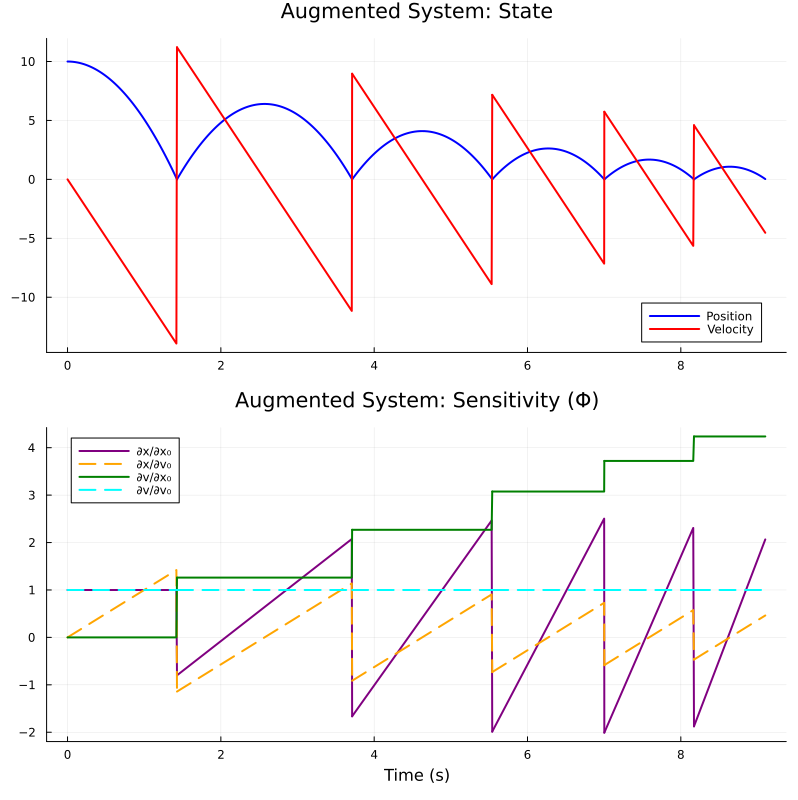

In [13]:
p2 = plt.plot(t_plot_aug, pos_a, label="Position", lw=2, color=:blue)
plt.plot!(p2, t_plot_aug, vel_a, label="Velocity", lw=2, color=:red)
plt.title!(p2, "Augmented System: State")

p3 = plt.plot(t_plot_aug, phi_11, label="∂x/∂x₀", lw=2, color=:purple)
plt.plot!(p3, t_plot_aug, phi_12, label="∂x/∂v₀", lw=2, color=:orange, linestyle=:dash)
plt.plot!(p3, t_plot_aug, phi_21, label="∂v/∂x₀", lw=2, color=:green)
plt.plot!(p3, t_plot_aug, phi_22, label="∂v/∂v₀", lw=2, color=:cyan, linestyle=:dash)
plt.title!(p3, "Augmented System: Sensitivity (Φ)")
plt.xlabel!(p3, "Time (s)")

final_plot = plt.plot(p2, p3, layout=(2,1), size=(800, 800))
display(final_plot)